# Experiment 8 : Clustering Human Activity Recognition Data using K-Means, DBSCAN, and Hierarchical Clustering


## Loading and EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

In [2]:
def load_dataset(filepath, column_names=None, separator=",",header=None):
    df = pd.read_csv(filepath, names=column_names, sep=separator,header=header)
    df.columns = df.columns.astype(str).str.strip()
    return df

def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-" * 50)
    print("\nShape: ", df.shape)
    print("\nColumns: ")
    print(df.columns.tolist())
    print("\nData Types: ")
    print(df.dtypes)
    print("\nMemory information")
    df.info()
    print("\nFirst 5 elements")
    print(df.head())

def missing_values(df):
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100
    result = pd.DataFrame({"missing": missing, "percent": percent})
    print(result)
    if missing.sum() == 0:
        print("There is no missing value!")
    else:
        print("\033[31mMissing Values detected\033[0m")
    return result

def duplicate_info(df):
    duplicates = df.duplicated().sum()
    print("\nThe duplicate rows are : ", duplicates)
    if duplicates == 0:
        print("No duplicates detected!")
    else:
        print("\033[31mDuplicates are detected\033[0m")
    return duplicates

def summary_statistics(df):
    print("\nSummary statistics")
    print(df.describe())

def class_distribution(df, target_column):
    print("\nClass Distribution")
    counts = df[target_column].value_counts()
    ax = counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")
    for container in ax.containers:
        ax.bar_label(container)
    plt.show()
    return counts

In [3]:
def perform_eda(filepath, column_names=None, separator=",", categorical_columns=None):
    df = load_dataset(filepath, column_names=column_names, separator=separator)
    print("\nLoading dataset completed\n")
    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)
    # plot_histogram(df)
    # plot_heatmap(df)
    if categorical_columns is not None:
        for col in categorical_columns:
            class_distribution(df, col)
    return df

In [4]:
X_train = load_dataset("dataset/train/X_train.txt",separator=r"\s+")

y_train = load_dataset("dataset/train/y_train.txt",separator=r"\s+")
y_train.columns = ["Activity"]

features = load_dataset("dataset/features.txt",separator=r"\s+")
feature_names = features.iloc[:,1].tolist()
X_train.columns = feature_names

activity_labels = load_dataset("dataset/activity_labels.txt",separator=r"\s+")
print("Loading dataset completed")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Loading dataset completed
X_train shape: (7352, 561)
y_train shape: (7352, 1)


In [5]:
print("X_train columns:", len(X_train.columns))
print("feature_names:", len(feature_names))
print("features shape:", features.shape)

print(features.head(10))
display(X_train.head())
display(y_train.head())

X_train columns: 561
feature_names: 561
features shape: (561, 2)
    0                  1
0   1  tBodyAcc-mean()-X
1   2  tBodyAcc-mean()-Y
2   3  tBodyAcc-mean()-Z
3   4   tBodyAcc-std()-X
4   5   tBodyAcc-std()-Y
5   6   tBodyAcc-std()-Z
6   7   tBodyAcc-mad()-X
7   8   tBodyAcc-mad()-Y
8   9   tBodyAcc-mad()-Z
9  10   tBodyAcc-max()-X


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


,Activity
0,5
1,5
2,5
3,5
4,5


## Numeric EDA

X Train
                                      missing  percent
tBodyAcc-mean()-X                           0      0.0
tBodyAcc-mean()-Y                           0      0.0
tBodyAcc-mean()-Z                           0      0.0
tBodyAcc-std()-X                            0      0.0
tBodyAcc-std()-Y                            0      0.0
...                                       ...      ...
angle(tBodyGyroMean,gravityMean)            0      0.0
angle(tBodyGyroJerkMean,gravityMean)        0      0.0
angle(X,gravityMean)                        0      0.0
angle(Y,gravityMean)                        0      0.0
angle(Z,gravityMean)                        0      0.0

[561 rows x 2 columns]
There is no missing value!
Y Train
          missing  percent
Activity        0      0.0
There is no missing value!

The duplicate rows are :  0
No duplicates detected!

Summary statistics
       tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
count        7352.000000        7352.000000        73

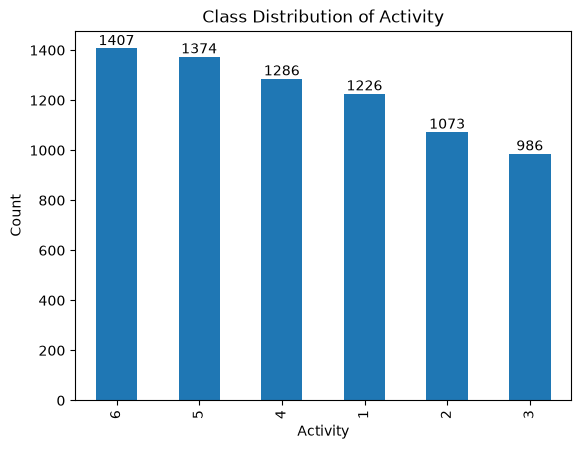

Activity
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64

In [6]:
print("X Train")
missing_values(X_train)
print("Y Train")
missing_values(y_train)

duplicate_info(X_train)
summary_statistics(X_train)

class_distribution(y_train,"Activity")

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train.values)

print(X_scaled.shape)
print(type(X_scaled))

print("Mean: ",X_scaled.mean(axis=0)[:5])
print("Std: ",X_scaled.std(axis=0)[:5])


(7352, 561)
<class 'numpy.ndarray'>
Mean:  [-3.13133632e-16  4.78398605e-17  8.69815645e-17 -1.50768045e-16
  0.00000000e+00]
Std:  [1. 1. 1. 1. 1.]


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print("Explained variance: ",pca.explained_variance_ratio_)

(7352, 2)
Explained variance:  [0.50781172 0.0658068 ]


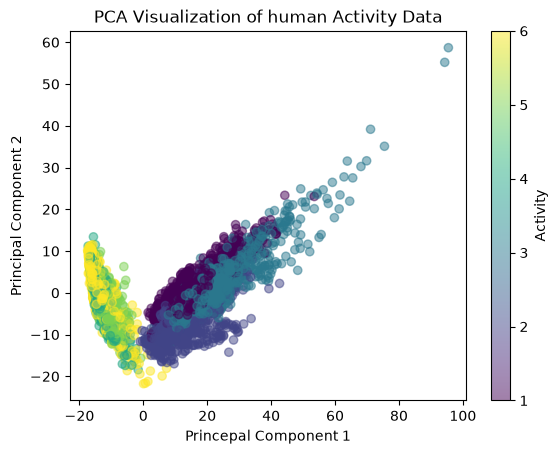

In [9]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=y_train["Activity"],
            alpha=0.5)
plt.xlabel("Princepal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of human Activity Data")
plt.colorbar(label="Activity")

plt.show()

# Performing Clustering

## 1. K-Means

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [11]:
wcss = []
silhoette_scores=[]

for k in range(2,9):
    kmeans = KMeans(n_clusters=k,n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    silhoette_scores.append(silhouette_score(X_scaled,labels))

print("WCSS: ",wcss)
print("Silhouette Scores: ",silhoette_scores)

WCSS:  [2336223.752002104, 2081849.6271975671, 1976452.6430191211, 1875066.0899230514, 1818790.0682136691, 1776518.7291605172, 1737555.4358311314]
Silhouette Scores:  [0.39650494031412553, 0.3274077920801446, 0.1651628752674826, 0.1306386109231235, 0.1086410631864108, 0.11142407811150756, 0.07386062149068542]


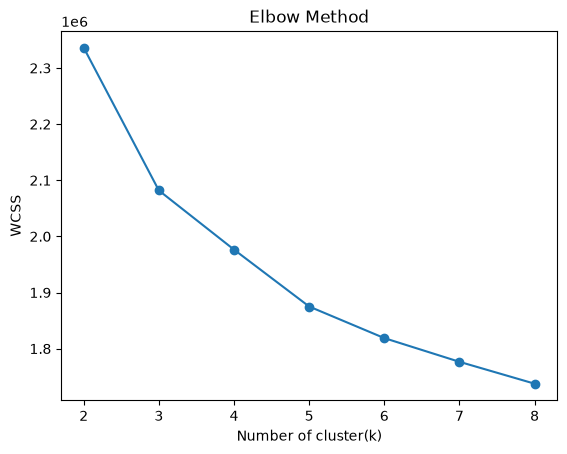

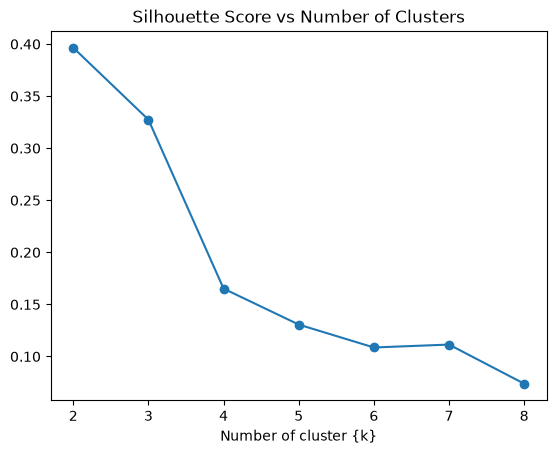

In [12]:
k_values = range(2,9)

plt.plot(k_values,wcss,marker="o")
plt.xlabel("Number of cluster(k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

plt.plot(k_values,silhoette_scores,marker="o")
plt.xlabel("Number of cluster {k}")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

### K Means Model
- THere was no significant drop/elbow point observed in k = 2->8
- We can see for k=2 it has the highest silhouette Score

- The Silhouette Score was highest at k = 2. However, considering
the clustering structure of the dataset and the specified search
range, k = 8 was selected for the final K-Means clustering.

In [13]:
kmeans = KMeans(n_clusters=8,n_init=10,random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
print("Cluster labels: ",kmeans_labels[:20])
print("number of clusters: ",len(set(kmeans_labels)))
print("Cluster sizes:", np.bincount(kmeans_labels))

Cluster labels:  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 4 4 1 1 1 1]
number of clusters:  8
Cluster sizes: [ 205 1460 1143 1060 1122  268 1214  880]


### Internal Evaluation

The final K-Means clustering is evaluated using internal clustering
metrics:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index


In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

kmeans_silhouette = silhouette_score(X_scaled,kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled,kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled,kmeans_labels)

print("Silhouette Score:", kmeans_silhouette)
print("Davies-Bouldin Index:", kmeans_db)
print("Calinski-Harabasz Index:", kmeans_ch)


Silhouette Score: 0.07386062149068542
Davies-Bouldin Index: 2.584100344029868
Calinski-Harabasz Index: 1441.2296794984773


### External Evaluation

The final K-Means clusters are compared with the ground-truth
activity labels using:

- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

In [15]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

ari = adjusted_rand_score(y_train["Activity"],kmeans_labels)

nmi = normalized_mutual_info_score(y_train["Activity"],kmeans_labels)

print("ARI: ",ari)
print("NMI: ",nmi)

ARI:  0.43612260111956563
NMI:  0.5581908013084234


### K-Means Cluster Visualization

The final K-Means clusters are visualized using the two principal
components obtained earlier through PCA.

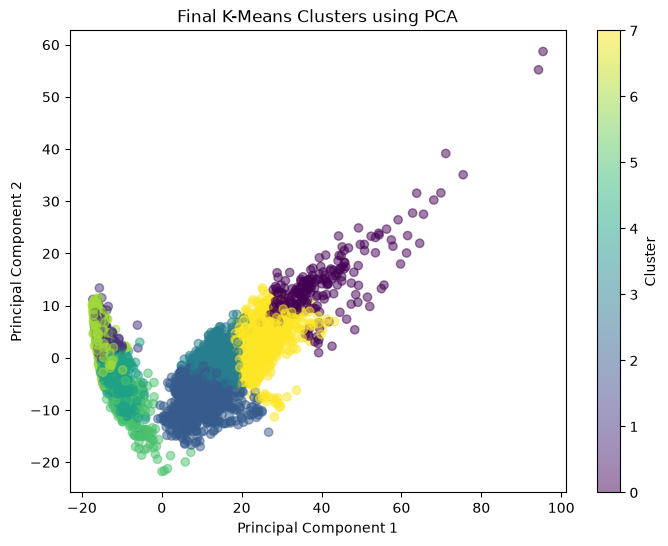

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Final K-Means Clusters using PCA")

plt.colorbar(label="Cluster")

plt.show()

# DBScan Clustering


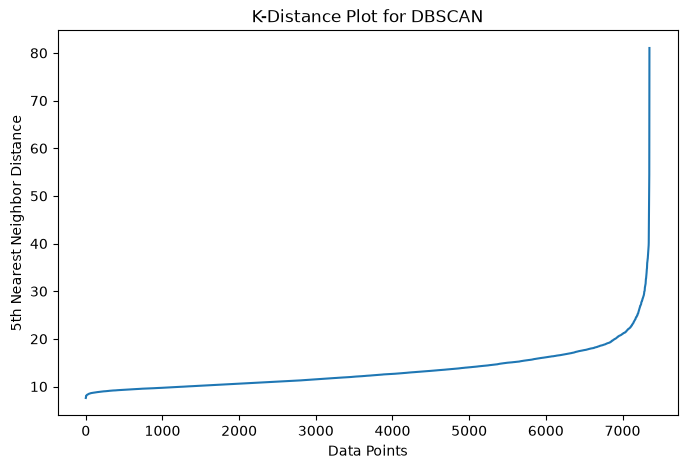

In [17]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances,indices = neighbors_fit.kneighbors(X_scaled)

k_distances = distances[:,4]

k_distances = np.sort(k_distances)

plt.figure(figsize=(8,5))
plt.plot(k_distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")
plt.show()

## Different eps and min_samples

In [18]:
from sklearn.cluster import DBSCAN

eps_values = [15, 18, 20, 22, 24, 26]
min_samples_values = [5, 10, 15]

dbscan_results=[]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps,min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        dbscan_results.append([eps,min_samples,n_clusters,n_noise])

dbscan_results

[[15, 5, 15, np.int64(1387)],
 [15, 10, 4, np.int64(1623)],
 [15, 15, 1, np.int64(1775)],
 [18, 5, 3, np.int64(508)],
 [18, 10, 2, np.int64(590)],
 [18, 15, 2, np.int64(650)],
 [20, 5, 2, np.int64(295)],
 [20, 10, 1, np.int64(337)],
 [20, 15, 1, np.int64(369)],
 [22, 5, 2, np.int64(193)],
 [22, 10, 1, np.int64(222)],
 [22, 15, 1, np.int64(243)],
 [24, 5, 1, np.int64(128)],
 [24, 10, 1, np.int64(149)],
 [24, 15, 1, np.int64(156)],
 [26, 5, 1, np.int64(89)],
 [26, 10, 1, np.int64(102)],
 [26, 15, 1, np.int64(107)]]

## Putting results into a Table

In [19]:
import pandas as pd

dbscan_results = pd.DataFrame(dbscan_results,columns=["eps","min_samples",
                                                      "clusters","noise"]
                             )
print(dbscan_results)

    eps  min_samples  clusters  noise
0    15            5        15   1387
1    15           10         4   1623
2    15           15         1   1775
3    18            5         3    508
4    18           10         2    590
5    18           15         2    650
6    20            5         2    295
7    20           10         1    337
8    20           15         1    369
9    22            5         2    193
10   22           10         1    222
11   22           15         1    243
12   24            5         1    128
13   24           10         1    149
14   24           15         1    156
15   26            5         1     89
16   26           10         1    102
17   26           15         1    107


## Evaluate Candidate DBSCAN

In [20]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

metric_results=[]

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(eps=eps,min_samples=min_samples)

        labels = dbscan.fit_predict(X_scaled)

        #Remove noise for metric cal
        mask = labels !=-1

        filtered_X = X_scaled[mask]
        filtered_labels = labels[mask]

        n_clusters = len(set(filtered_labels))

        if n_clusters >= 2:
            silhouette = silhouette_score(filtered_X,filtered_labels)
            db = davies_bouldin_score(filtered_X,filtered_labels)
            ch = calinski_harabasz_score(filtered_X,filtered_labels)
        else:
            silhouette = np.nan
            db = np.nan
            ch = np.nan
        metric_results.append([eps,min_samples,n_clusters,np.sum(labels ==-1),
                    silhouette,db, ch])
dbscan_metrics = pd.DataFrame(metric_results,columns=["eps","min_samples","clusters",
                    "noise","silhouette","davied_bouldin","calinkski_harabasz"])
print(dbscan_metrics)

    eps  min_samples  clusters  noise  silhouette  davied_bouldin  \
0    15            5        15   1387    0.174182        1.248313   
1    15           10         4   1623    0.231234        0.976545   
2    15           15         1   1775         NaN             NaN   
3    18            5         3    508    0.228626        1.265131   
4    18           10         2    590    0.319603        0.939813   
5    18           15         2    650    0.321495        0.924026   
6    20            5         2    295    0.355583        0.796353   
7    20           10         1    337         NaN             NaN   
8    20           15         1    369         NaN             NaN   
9    22            5         2    193    0.335230        0.940550   
10   22           10         1    222         NaN             NaN   
11   22           15         1    243         NaN             NaN   
12   24            5         1    128         NaN             NaN   
13   24           10         1    

In [21]:
print(dbscan_metrics.sort_values(by="silhouette",ascending=False))

    eps  min_samples  clusters  noise  silhouette  davied_bouldin  \
6    20            5         2    295    0.355583        0.796353   
9    22            5         2    193    0.335230        0.940550   
5    18           15         2    650    0.321495        0.924026   
4    18           10         2    590    0.319603        0.939813   
1    15           10         4   1623    0.231234        0.976545   
3    18            5         3    508    0.228626        1.265131   
0    15            5        15   1387    0.174182        1.248313   
2    15           15         1   1775         NaN             NaN   
7    20           10         1    337         NaN             NaN   
8    20           15         1    369         NaN             NaN   
10   22           10         1    222         NaN             NaN   
11   22           15         1    243         NaN             NaN   
12   24            5         1    128         NaN             NaN   
13   24           10         1    

## Select Final Parameters

In [22]:
best_eps = 20
best_min_samples = 5

## Selection of DBSCAN Parameters
- using k-distance plot and differnt combination of eps and min_samples

In [23]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise = np.sum(dbscan_labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 2
Number of noise points: 295


## Internal Metrics

In [24]:
mask = dbscan_labels != -1

X_dbscan = X_scaled[mask]
labels_dbscan = dbscan_labels[mask]

dbscan_silhouette = silhouette_score(X_dbscan,labels_dbscan)
dbscan_db = davies_bouldin_score(X_dbscan,labels_dbscan)
dbscan_ch = calinski_harabasz_score(
    X_dbscan,
    labels_dbscan )

print("Silhouette Score:", dbscan_silhouette)
print("Davies-Bouldin Index:", dbscan_db)
print("Calinski-Harabasz Index:", dbscan_ch)

Silhouette Score: 0.3555827282784337
Davies-Bouldin Index: 0.796353327134828
Calinski-Harabasz Index: 15.23371413759661


## External Metrics

In [25]:
from sklearn.metrics import (adjusted_rand_score,normalized_mutual_info_score)

dbscan_ari = adjusted_rand_score( y_train["Activity"],dbscan_labels)
dbscan_nmi = normalized_mutual_info_score(y_train["Activity"],dbscan_labels)

print("ARI: ",dbscan_ari)
print("NMI: ",dbscan_nmi)

ARI:  0.006356325348566534
NMI:  0.032976415631163644


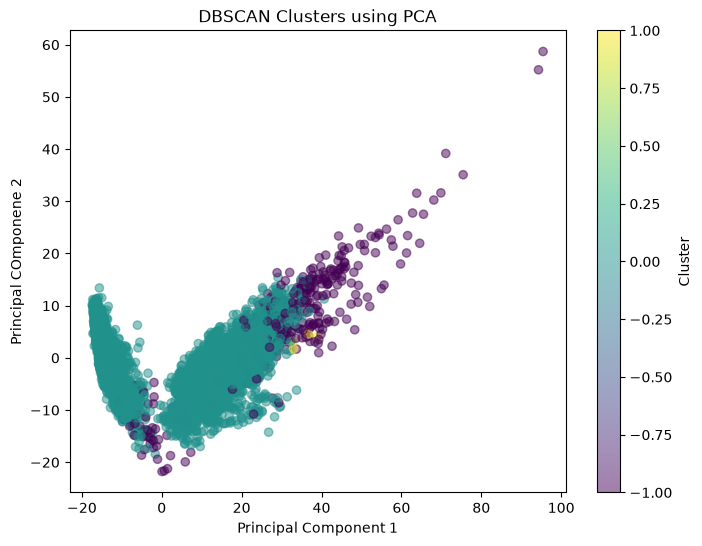

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=dbscan_labels,alpha=0.5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal COmponene 2")
plt.title("DBSCAN Clusters using PCA")
plt.colorbar(label="Cluster")

plt.show()

# Hierarchical Agglomerative Clustering

In [28]:
from scipy.cluster.hierarchy import linkage
Z = linkage(X_scaled,method="ward")
print("Linkage matrix shape:",Z.shape)

Linkage matrix shape: (7351, 4)


## Dendogram
- TO determine cluster size

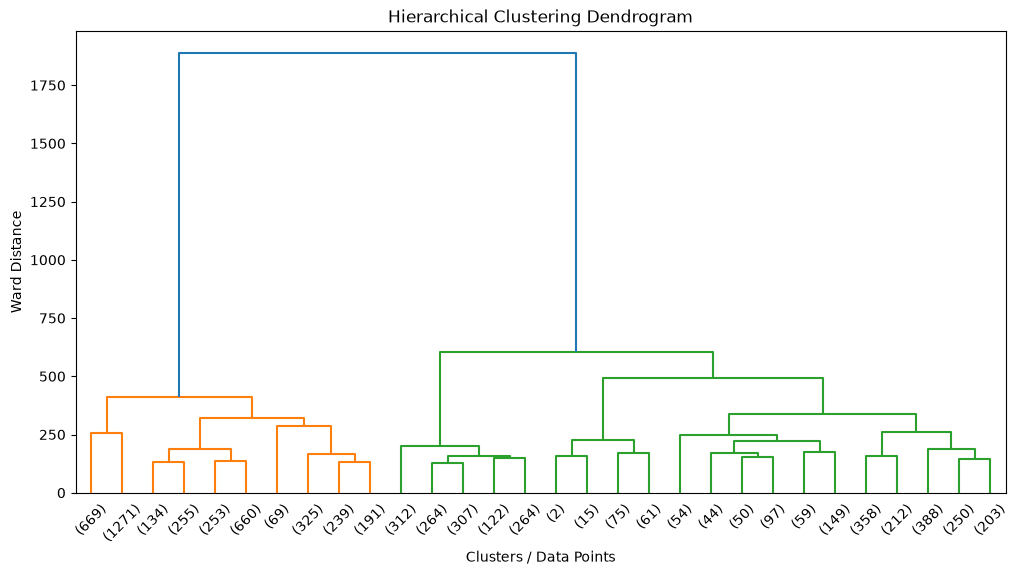

In [29]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters / Data Points")
plt.ylabel("Ward Distance")

plt.show()

In [30]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

hierarchical_results = []

for n in range(2, 9):

    hierarchical = AgglomerativeClustering(
        n_clusters=n,
        linkage="ward"
    )

    labels = hierarchical.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    db = davies_bouldin_score(
        X_scaled,
        labels
    )

    ch = calinski_harabasz_score(
        X_scaled,
        labels
    )

    hierarchical_results.append([
        n,
        silhouette,
        db,
        ch
    ])

In [31]:
hierarchical_results = pd.DataFrame(
    hierarchical_results,
    columns=[
        "n_clusters",
        "silhouette",
        "davies_bouldin",
        "calinski_harabasz"
    ]
)

print(hierarchical_results)

   n_clusters  silhouette  davies_bouldin  calinski_harabasz
0           2    0.396056        1.069820        5608.277236
1           3    0.254790        1.927494        3350.021309
2           4    0.256773        1.966691        2514.074527
3           5    0.087373        2.485168        2045.913931
4           6    0.083396        2.785733        1730.835839
5           7    0.085848        2.735448        1516.473072
6           8    0.087636        2.527295        1352.831756


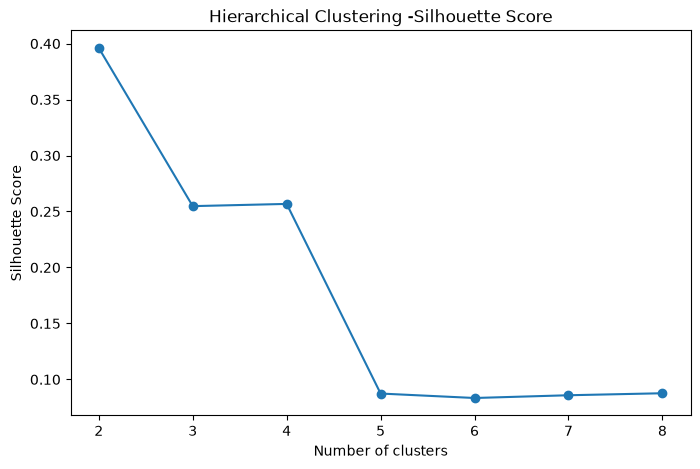

In [33]:
plt.figure(figsize = (8,5))
plt.plot(hierarchical_results["n_clusters"],
         hierarchical_results["silhouette"],
         marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering -Silhouette Score")
plt.show()

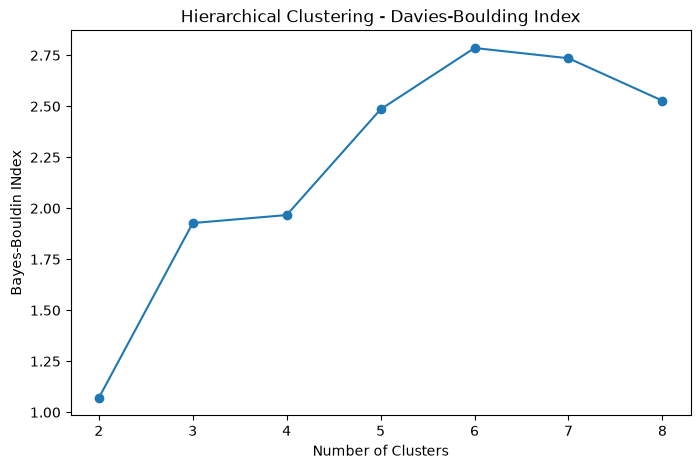

In [34]:
plt.figure(figsize=(8,5))
plt.plot(hierarchical_results["n_clusters"],hierarchical_results["davies_bouldin"],
         marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Bayes-Bouldin INdex")
plt.title("Hierarchical Clustering - Davies-Boulding Index")

plt.show()

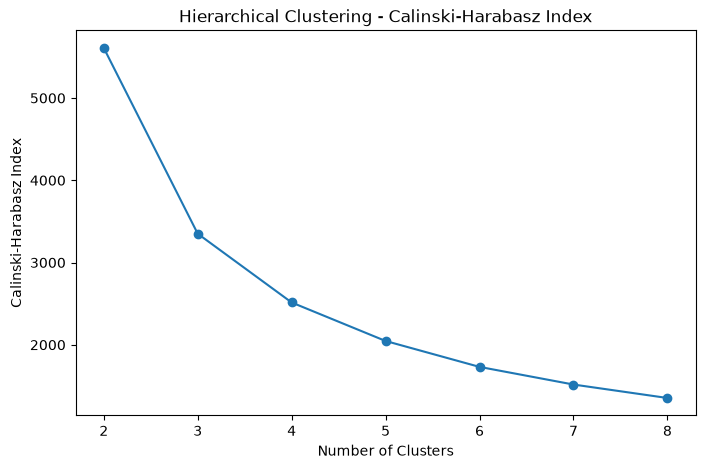

In [37]:
plt.figure(figsize=(8,5))

plt.plot(hierarchical_results["n_clusters"],
    hierarchical_results["calinski_harabasz"],
         marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Calinski-Harabasz Index")
plt.title("Hierarchical Clustering - Calinski-Harabasz Index")

plt.show()

## Selection of clusters
The clustering evaluation metrics also strongly supported
n_clusters = 2. The Silhouette Score was highest at 2 clusters
(0.3961), the Davies-Bouldin Index was lowest at 2 clusters
(1.0698), and the Calinski-Harabasz Index was highest at 2 clusters
(5608.28).

In [38]:
hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

print("Number of clusters:", len(set(hierarchical_labels)))
print("Cluster sizes:", np.bincount(hierarchical_labels))

Number of clusters: 2
Cluster sizes: [3286 4066]


## Internal Metrics

In [41]:
from sklearn.metrics import (silhouette_score,davies_bouldin_score)
from sklearn.metrics import calinski_harabasz_score

hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hierarchical_db = davies_bouldin_score(X_scaled,hierarchical_labels)
hierarchical_ch = calinski_harabasz_score(X_scaled, hierarchical_labels)

print("Silhouette Score:", hierarchical_silhouette)
print("Davies-Bouldin Index:", hierarchical_db)
print("Calinski-Harabasz Index:", hierarchical_ch)

Silhouette Score: 0.396055785173182
Davies-Bouldin Index: 1.0698200599468044
Calinski-Harabasz Index: 5608.277235809429


## External Metrics

In [43]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

hierarchical_ari = adjusted_rand_score(y_train["Activity"],hierarchical_labels)
hierarchical_nmi = normalized_mutual_info_score(y_train["Activity"],hierarchical_labels)

print("ARI: ",hierarchical_ari)
print("NMI: ",hierarchical_nmi)

ARI:  0.3318660814332718
NMI:  0.5554769266122497


## PCA Visualization

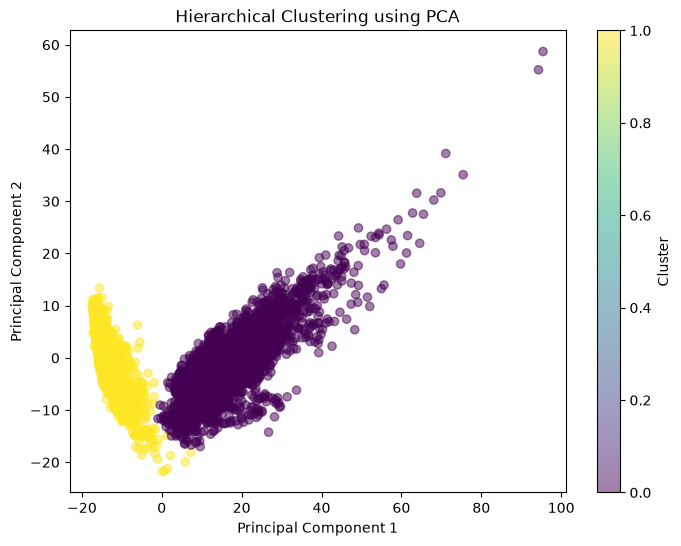

In [45]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=hierarchical_labels,alpha=0.5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering using PCA")
plt.colorbar(label="Cluster")

plt.show()

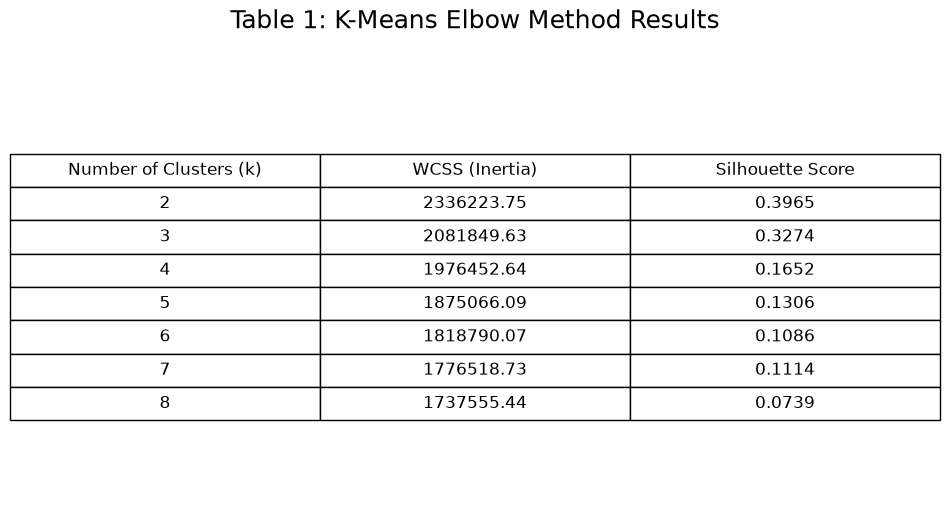

In [49]:
import matplotlib.pyplot as plt

k_values = list(range(2, 9))

kmeans_table = []

for i in range(len(k_values)):
    kmeans_table.append([
        k_values[i],
        f"{wcss[i]:.2f}",
        f"{silhoette_scores[i]:.4f}"
    ])

fig, ax = plt.subplots(figsize=(12, 6))

ax.axis("off")

table = ax.table(
    cellText=kmeans_table,
    colLabels=[
        "Number of Clusters (k)",
        "WCSS (Inertia)",
        "Silhouette Score"
    ],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

plt.title(
    "Table 1: K-Means Elbow Method Results",
    fontsize=18,
    pad=20
)

plt.show()

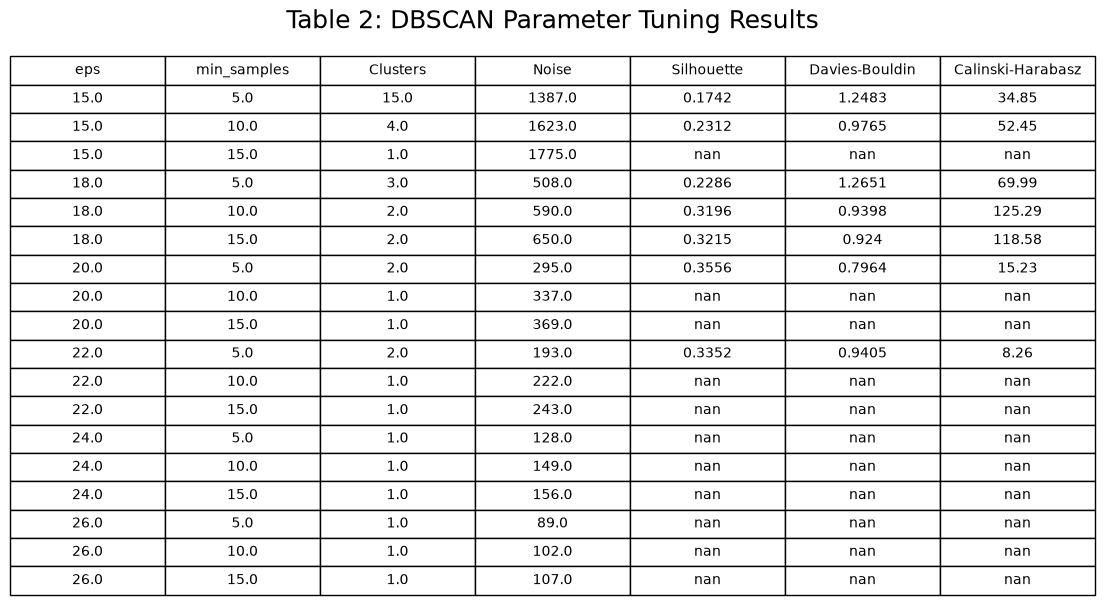

In [52]:
dbscan_table = dbscan_metrics.copy()

dbscan_table["silhouette"] = (
    dbscan_table["silhouette"].round(4)
)

dbscan_table["davied_bouldin"] = (
    dbscan_table["davied_bouldin"].round(4)
)

dbscan_table["calinkski_harabasz"] = (
    dbscan_table["calinkski_harabasz"].round(2)
)

fig, ax = plt.subplots(figsize=(14, 7))

ax.axis("off")

table = ax.table(
    cellText=dbscan_table.values,
    colLabels=[
        "eps",
        "min_samples",
        "Clusters",
        "Noise",
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz"
    ],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.7)

plt.title(
    "Table 2: DBSCAN Parameter Tuning Results",
    fontsize=18,
    pad=20
)

plt.show()

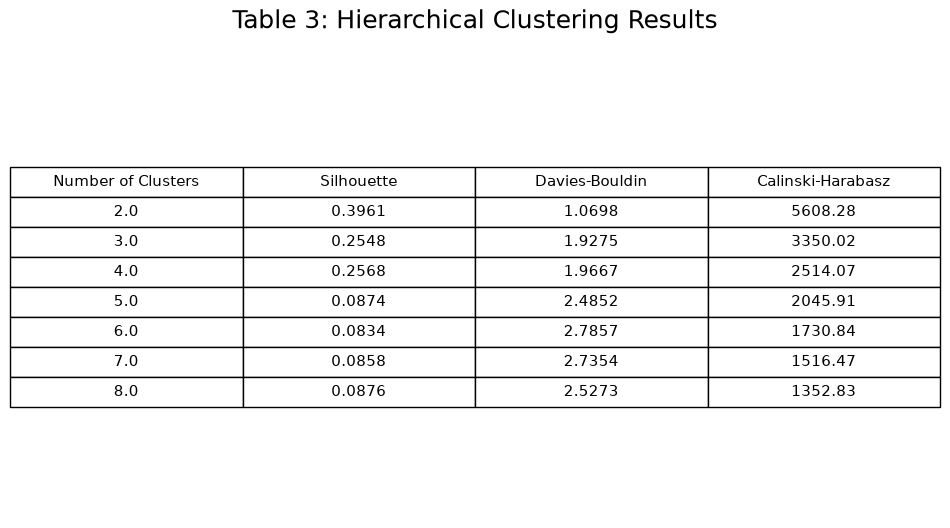

In [51]:
hierarchical_table = hierarchical_results.copy()

hierarchical_table["silhouette"] = (
    hierarchical_table["silhouette"].round(4)
)

hierarchical_table["davies_bouldin"] = (
    hierarchical_table["davies_bouldin"].round(4)
)

hierarchical_table["calinski_harabasz"] = (
    hierarchical_table["calinski_harabasz"].round(2)
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.axis("off")

table = ax.table(
    cellText=hierarchical_table.values,
    colLabels=[
        "Number of Clusters",
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz"
    ],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

plt.title(
    "Table 3: Hierarchical Clustering Results",
    fontsize=18,
    pad=20
)

plt.show()